In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rishiksaisanthosh/brain-tumour-classification")

print("Path to dataset files:", path)

100%|██████████| 491M/491M [00:04<00:00, 108MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/rishiksaisanthosh/brain-tumour-classification/versions/1


In [ ]:
import os

dataset_path = "/root/.cache/kagglehub/datasets/rishiksaisanthosh/brain-tumour-classification/versions/1"

for root, dirs, files in os.walk(dataset_path):
    print(root, dirs[:5], len(files))


/root/.cache/kagglehub/datasets/rishiksaisanthosh/brain-tumour-classification/versions/1 ['BrainTumor_1'] 0
/root/.cache/kagglehub/datasets/rishiksaisanthosh/brain-tumour-classification/versions/1/BrainTumor_1 ['Test', 'Train'] 0
/root/.cache/kagglehub/datasets/rishiksaisanthosh/brain-tumour-classification/versions/1/BrainTumor_1/Test ['pituitary', 'glioma', 'meningioma', 'notumor'] 0
/root/.cache/kagglehub/datasets/rishiksaisanthosh/brain-tumour-classification/versions/1/BrainTumor_1/Test/pituitary [] 300
/root/.cache/kagglehub/datasets/rishiksaisanthosh/brain-tumour-classification/versions/1/BrainTumor_1/Test/glioma [] 300
/root/.cache/kagglehub/datasets/rishiksaisanthosh/brain-tumour-classification/versions/1/BrainTumor_1/Test/meningioma [] 306
/root/.cache/kagglehub/datasets/rishiksaisanthosh/brain-tumour-classification/versions/1/BrainTumor_1/Test/notumor [] 405
/root/.cache/kagglehub/datasets/rishiksaisanthosh/brain-tumour-classification/versions/1/BrainTumor_1/Train ['pituitary'

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.models import Sequential
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np
import time
from google.colab import files
from tensorflow.keras.preprocessing import image

# ---------------- Settings ----------------
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS_CNN = 20
EPOCHS_RESNET = 10

# Dataset paths
TRAIN_DIR = "/root/.cache/kagglehub/datasets/rishiksaisanthosh/brain-tumour-classification/versions/1/BrainTumor_1/Train"
TEST_DIR  = "/root/.cache/kagglehub/datasets/rishiksaisanthosh/brain-tumour-classification/versions/1/BrainTumor_1/Test"

# Class names (alphabetical order from folder names)
CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']
NUM_CLASSES = len(CLASS_NAMES)


In [ ]:
# ---------------- Load training dataset ----------------
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# ---------------- Load test dataset ----------------
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# Prefetch for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.prefetch(buffer_size=AUTOTUNE)


Found 22848 files belonging to 4 classes.
Using 18279 files for training.
Found 22848 files belonging to 4 classes.
Using 4569 files for validation.
Found 1311 files belonging to 4 classes.


In [ ]:
data_augmentation = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.2)
])

In [ ]:
def build_custom_cnn():
    weight_decay = 1e-4

    model = Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        data_augmentation,
        layers.Rescaling(1./255),

        layers.Conv2D(32, 3, padding='same', activation='relu',
                      kernel_regularizer=tf.keras.regularizers.l2(weight_decay)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        layers.Conv2D(64, 3, padding='same', activation='relu',
                      kernel_regularizer=tf.keras.regularizers.l2(weight_decay)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        layers.GlobalAveragePooling2D(),

        layers.Dense(64, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(weight_decay)),
        layers.Dropout(0.5),

        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name="Custom_CNN")

    return model

custom_model = build_custom_cnn()

custom_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)



In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


=== Training Custom CNN ===
Epoch 1/20
572/572 ━━━━━━━━━━━━━━━━━━━━ 88s 136ms/step - accuracy: 0.3485 - loss: 1.4314 - val_accuracy: 0.5163 - val_loss: 1.2187
Epoch 2/20
572/572 ━━━━━━━━━━━━━━━━━━━━ 135s 137ms/step - accuracy: 0.5012 - loss: 1.1419 - val_accuracy: 0.4546 - val_loss: 1.1674
Epoch 3/20
572/572 ━━━━━━━━━━━━━━━━━━━━ 81s 135ms/step - accuracy: 0.5309 - loss: 1.1008 - val_accuracy: 0.5014 - val_loss: 1.1612
Epoch 4/20
572/572 ━━━━━━━━━━━━━━━━━━━━ 78s 136ms/step - accuracy: 0.5518 - loss: 1.0695 - val_accuracy: 0.5104 - val_loss: 1.1269
Epoch 5/20
572/572 ━━━━━━━━━━━━━━━━━━━━ 82s 143ms/step - accuracy: 0.5625 - loss: 1.0462 - val_accuracy: 0.5084 - val_loss: 1.1226
Epoch 6/20
572/572 ━━━━━━━━━━━━━━━━━━━━ 78s 137ms/step - accuracy: 0.5711 - loss: 1.0298 - val_accuracy: 0.5218 - val_loss: 1.1260
Epoch 7/20
572/572 ━━━━━━━━━━━━━━━━━━━━ 81s 135ms/step - accuracy: 0.5695 - loss: 1.0232 - val_accuracy: 0.5014 - val_loss: 1.1318
Epoch 8/20
572/572 ━━━━━━━━━━━━━━━━━━━━ 78s 136ms/step

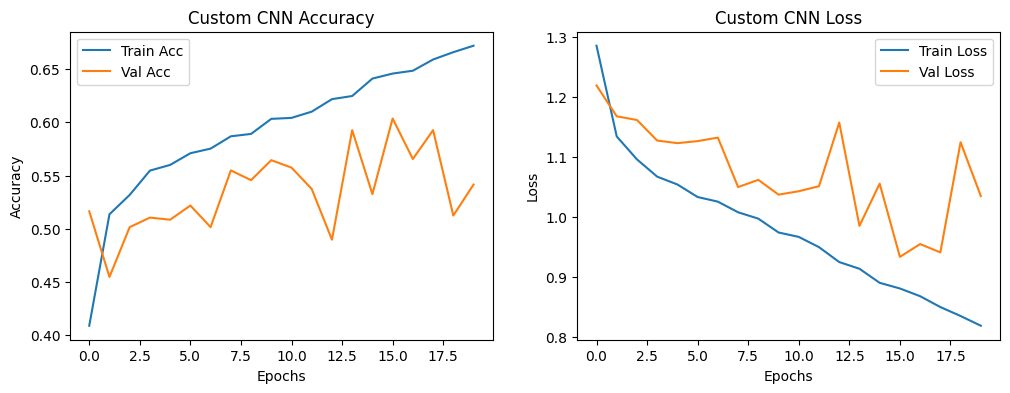

In [ ]:
print("=== Training Custom CNN ===")
start_time = time.time()

history_cnn = custom_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_CNN,
    callbacks=[early_stop],
    verbose=1
)

cnn_train_time = time.time() - start_time

# Plot training & validation accuracy/loss
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_cnn.history['accuracy'], label='Train Acc')
plt.plot(history_cnn.history['val_accuracy'], label='Val Acc')
plt.title("Custom CNN Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Val Loss')
plt.title("Custom CNN Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()


In [ ]:
def build_resnet_model():
    base_model = tf.keras.applications.ResNet50(input_shape=(IMG_SIZE, IMG_SIZE, 3),
                                                include_top=False,
                                                weights='imagenet')
    base_model.trainable = False
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = data_augmentation(inputs)
    x = tf.keras.applications.resnet50.preprocess_input(x)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return models.Model(inputs, outputs), base_model

# Build and compile
resnet_model, base_model = build_resnet_model()
resnet_model.compile(optimizer=optimizers.Adam(1e-3),
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

# --- Phase 1: Frozen Base ---
print("=== Training ResNet50 (Frozen Base) ===")
start_time = time.time()
history_resnet_frozen = resnet_model.fit(train_ds,
                                         validation_data=val_ds,
                                         epochs=5,
                                         verbose=1)

# --- Phase 2: Fine-Tuning ---
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

resnet_model.compile(optimizer=optimizers.Adam(1e-5),
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])
print("=== Fine-Tuning ResNet50 ===")
history_resnet_ft = resnet_model.fit(train_ds,
                                    validation_data=val_ds,
                                    epochs=EPOCHS_RESNET,
                                    verbose=1)
resnet_train_time = time.time() - start_time


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
=== Training ResNet50 (Frozen Base) ===
Epoch 1/5
572/572 ━━━━━━━━━━━━━━━━━━━━ 104s 166ms/step - accuracy: 0.7475 - loss: 0.6942 - val_accuracy: 0.8750 - val_loss: 0.3256
Epoch 2/5
572/572 ━━━━━━━━━━━━━━━━━━━━ 92s 161ms/step - accuracy: 0.8638 - loss: 0.3614 - val_accuracy: 0.8755 - val_loss: 0.3487
Epoch 3/5
572/572 ━━━━━━━━━━━━━━━━━━━━ 95s 167ms/step - accuracy: 0.8860 - loss: 0.3085 - val_accuracy: 0.8917 - val_loss: 0.2754
Epoch 4/5
572/572 ━━━━━━━━━━━━━━━━━━━━ 92s 161ms/step - accuracy: 0.8919 - loss: 0.2877 - val_accuracy: 0.8954 - val_loss: 0.2740
Epoch 5/5
572/572 ━━━━━━━━━━━━━━━━━━━━ 95s 167ms/step - accuracy: 0.8980 - loss: 0.2713 - val_accuracy: 0.9074 - val_loss: 0.2631
=== Fine-Tuning ResNet50 ===
Epoch 1/10
572/572 ━━━━━━━━━━━━━━━━━━━━ 123s 196ms/step - accuracy: 0.9046 - loss: 0.2551 - val_accuracy: 0.9050 - val_loss: 0.2777
Epoch 2/10
572/572 ━━━━━━━━━━━━━━━━━━━━ 109s 191ms/step - accuracy: 0.9294 - loss: 0.1879 - val_a

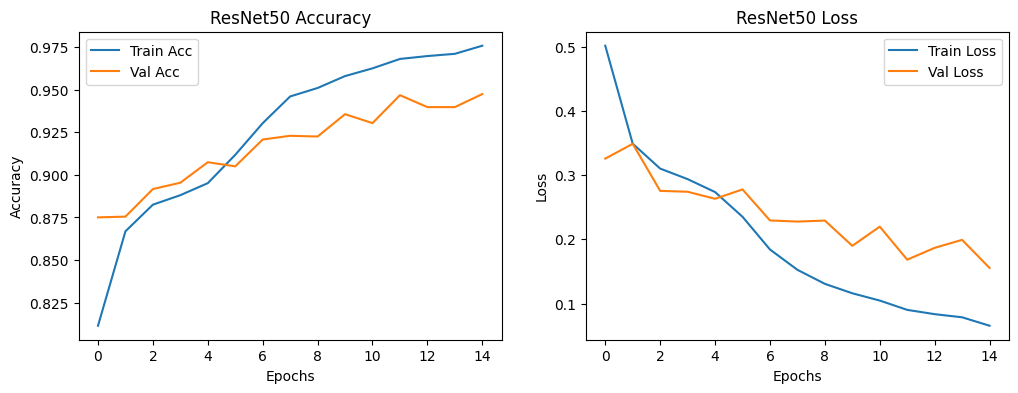

In [ ]:
train_acc = history_resnet_frozen.history['accuracy'] + history_resnet_ft.history['accuracy']
val_acc   = history_resnet_frozen.history['val_accuracy'] + history_resnet_ft.history['val_accuracy']
train_loss = history_resnet_frozen.history['loss'] + history_resnet_ft.history['loss']
val_loss   = history_resnet_frozen.history['val_loss'] + history_resnet_ft.history['val_loss']

# --- Plot ResNet accuracy & loss ---
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(train_acc, label='Train Acc')
plt.plot(val_acc, label='Val Acc')
plt.title("ResNet50 Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.title("ResNet50 Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()


Custom CNN Classification Report:
              precision    recall  f1-score   support

      glioma       0.53      0.17      0.26       300
  meningioma       0.60      0.02      0.04       306
     notumor       0.78      0.79      0.79       405
   pituitary       0.38      1.00      0.55       300

    accuracy                           0.52      1311
   macro avg       0.57      0.49      0.41      1311
weighted avg       0.59      0.52      0.44      1311



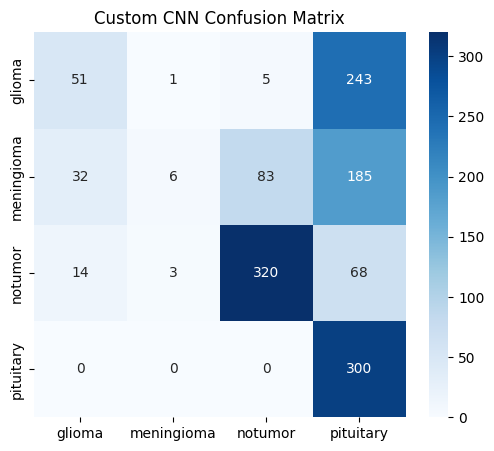


ResNet50 Classification Report:
              precision    recall  f1-score   support

      glioma       0.96      0.89      0.92       300
  meningioma       0.92      0.87      0.90       306
     notumor       1.00      1.00      1.00       405
   pituitary       0.88      1.00      0.94       300

    accuracy                           0.94      1311
   macro avg       0.94      0.94      0.94      1311
weighted avg       0.94      0.94      0.94      1311



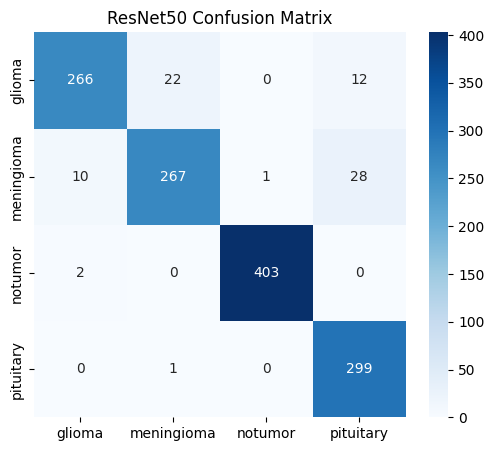

Custom CNN Train Time: 1655.47 sec
ResNet50 Train Time: 1658.89 sec


In [ ]:
def evaluate_model(model, name, dataset):
    y_true, y_pred = [], []
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(np.argmax(labels.numpy(), axis=1))

    print(f"\n{name} Classification Report:")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES,
                yticklabels=CLASS_NAMES)
    plt.title(f"{name} Confusion Matrix")
    plt.show()

# Evaluate
evaluate_model(custom_model, "Custom CNN", test_ds)
evaluate_model(resnet_model, "ResNet50", test_ds)

# Training time
print(f"Custom CNN Train Time: {cnn_train_time:.2f} sec")
print(f"ResNet50 Train Time: {resnet_train_time:.2f} sec")

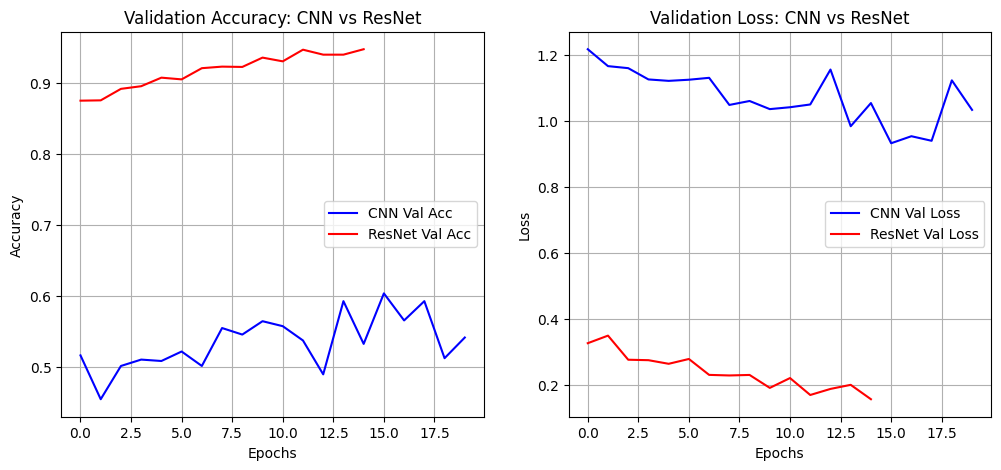

In [ ]:
# ==========================
# Combine ResNet histories
# ==========================
val_acc_resnet = history_resnet_frozen.history['val_accuracy'] + history_resnet_ft.history['val_accuracy']
val_loss_resnet = history_resnet_frozen.history['val_loss'] + history_resnet_ft.history['val_loss']

# ==========================
# Plot comparison: CNN vs ResNet (Validation Only)
# ==========================
plt.figure(figsize=(12,5))

# Validation Accuracy
plt.subplot(1,2,1)
plt.plot(history_cnn.history['val_accuracy'], label='CNN Val Acc', color='blue')
plt.plot(val_acc_resnet, label='ResNet Val Acc', color='red')
plt.title("Validation Accuracy: CNN vs ResNet")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Validation Loss
plt.subplot(1,2,2)
plt.plot(history_cnn.history['val_loss'], label='CNN Val Loss', color='blue')
plt.plot(val_loss_resnet, label='ResNet Val Loss', color='red')
plt.title("Validation Loss: CNN vs ResNet")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()


Saving images (19).jpg to images (19).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


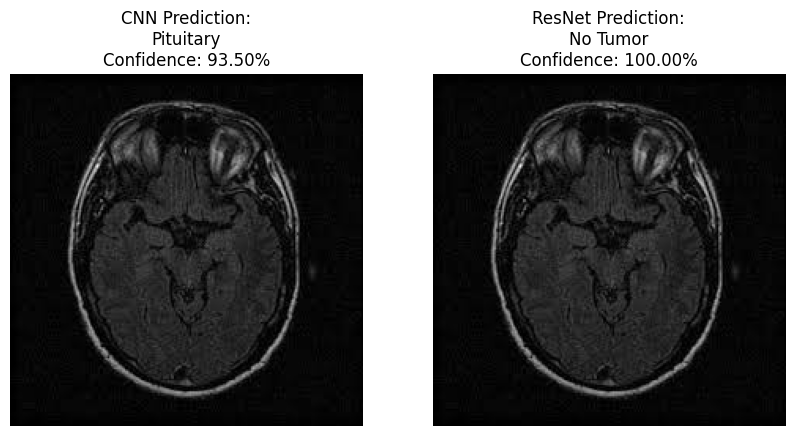

=== Custom CNN Probabilities ===
Glioma: 4.92%
Meningioma: 0.94%
No Tumor: 0.63%
Pituitary: 93.50%

=== ResNet50 Probabilities ===
Glioma: 0.00%
Meningioma: 0.00%
No Tumor: 100.00%
Pituitary: 0.00%


In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np

# --- Real class names matching your training dataset ---
REAL_CLASS_NAMES = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']

# --- Upload images ---
uploaded = files.upload()

for img_path in uploaded.keys():
    # Load and resize image
    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img)

    # Handle grayscale images
    if img_array.shape[-1] == 1:
        img_array = np.repeat(img_array, 3, axis=-1)

    # Expand dims for batch size
    img_array = np.expand_dims(img_array, axis=0)

    # --- Predict using Custom CNN ---
    cnn_preds = custom_model.predict(img_array)
    cnn_idx = np.argmax(cnn_preds)
    cnn_label = REAL_CLASS_NAMES[cnn_idx]
    cnn_conf = cnn_preds[0][cnn_idx] * 100

    # --- Predict using ResNet50 ---
    resnet_preds = resnet_model.predict(img_array)
    resnet_idx = np.argmax(resnet_preds)
    resnet_label = REAL_CLASS_NAMES[resnet_idx]
    resnet_conf = resnet_preds[0][resnet_idx] * 100

    # --- Display side by side ---
    plt.figure(figsize=(10,5))

    # Custom CNN
    plt.subplot(1,2,1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"CNN Prediction:\n{cnn_label}\nConfidence: {cnn_conf:.2f}%")

    # ResNet50
    plt.subplot(1,2,2)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"ResNet Prediction:\n{resnet_label}\nConfidence: {resnet_conf:.2f}%")

    plt.show()

    # Optional: print all probabilities for both models
    print("=== Custom CNN Probabilities ===")
    for i, name in enumerate(REAL_CLASS_NAMES):
        print(f"{name}: {cnn_preds[0][i]*100:.2f}%")

    print("\n=== ResNet50 Probabilities ===")
    for i, name in enumerate(REAL_CLASS_NAMES):
        print(f"{name}: {resnet_preds[0][i]*100:.2f}%")
